# Modelagem e Validação — Machine Learning
## Projeto: Classificação ESG por Machine Learning
**Empresa:** NorthData Consulting  
**Dataset:** Public Company ESG Ratings  
**Fonte:** https://www.kaggle.com/datasets/alistairking/public-company-esg-ratings-dataset  
**Autor:** Phelipe C. S. Cota 
**Data:** 28/05/2026  

---

### Objetivo
Treinar e comparar modelos de Machine Learning para classificação do nível de risco ESG de empresas (total_level), aplicando estratégias de validação, otimização de hiperparâmetros e rastreamento de experimentos com MLflow.

### Estrutura do Notebook
1. Preparação do ambiente
2. Carregamento e split dos dados
3. Configuração do MLflow
4. Pipeline de pré-processamento (Gold)
5. Treinamento e comparação de modelos (Classificação)
6. Análise dos resultados (Classificação)
7. Modelagem e comparação de modelos (Regressão)
8. Análise dos resultados (Regressão)
9. Salvamento dos modelos finais para o MLflow

## 1. Preparação do ambiente

In [8]:
# Instala dependências necessárias:
!pip install mlflow scikit-learn pandas numpy matplotlib seaborn


[notice] A new release of pip is available: 26.1.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [9]:
# Importações

# ── Dados ─────────────────────────────────────────────────────
import pandas as pd
import numpy as np
from pathlib import Path

# ── Machine Learning ──────────────────────────────────────────
from sklearn.model_selection import (
    train_test_split,
    StratifiedKFold,
    cross_val_score,
    GridSearchCV
)
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import (
    StandardScaler,
    OrdinalEncoder,
    OneHotEncoder
)
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    f1_score,
    ConfusionMatrixDisplay
)

# ── MLflow ────────────────────────────────────────────────────
import mlflow
import mlflow.sklearn

# ── Visualização ──────────────────────────────────────────────
import matplotlib.pyplot as plt
import seaborn as sns

# ── Configurações ─────────────────────────────────────────────
pd.set_option("display.max_columns", None)
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.figsize"] = (12, 5)

print("Bibliotecas carregadas com sucesso!")

Bibliotecas carregadas com sucesso!


## 2. Carregamento e Split dos Dados

Os dados de teste devem ser isolados antes de qualquer pré-processamento. Se os dados forem primeiro normalizarmos e depois divididos, há a possibilidade de o modelo
aprender informações estatísticas do conjunto de teste (média, desvio padrão) durante o treino, efeito de **Data Leakage** (Vazamento de Dados), gerando uma falsa impressão de bom desempenho.


### 2.1 Tarefas de Machine Learning e Variável Alvo (Target)

* **<u>Para Classificação</u>:** A variável alvo será `total_level` , e categóricas: Low/Medium/High/Excellent. O resultado irá servir a Matriz de Criticidadee  Mapa de Riscos
* **<u>Para Regressão</u>:** A variável alvo será `total_score`, utlizando escala numérica (600 a 1536). O resultado irá servir ao Dashboard Principal (Ranking, Benchmarking, KPIs)

### 2.2 Desbalanceamento (Classificação)
A EDA revelou que ~70% dos dados são classe "Medium". Por isso será usado `stratify=y` no split da classificação com o objetivo de garantir que a proporção de cada classe seja mantida tanto no treino quanto no teste.

### 2.3 Métricas adequadas por tarefa
- **Classificação:** F1-Score Macro e Recall Macro
- **Regressão:** RMSE, MAE e R²


In [10]:
# ── Carrega a camada Silver ───────────────────────────────────
SILVER_PATH = Path("..") / "data" / "silver" / "data_silver.csv"
df = pd.read_csv(SILVER_PATH)

print(f"Dataset carregado: {df.shape[0]} linhas × {df.shape[1]} colunas")

# ── Variável alvo: Classificação ──────────────────────────────
print(f"\nDistribuição — total_level (Classificação):")
print(df["total_level"].value_counts())
print(f"\nProporção (%):")
print((df["total_level"].value_counts(normalize=True) * 100).round(2))

# ── Variável alvo: Regressão ──────────────────────────────────
print(f"\nEstatísticas — total_score (Regressão):")
print(df["total_score"].describe().round(2))

Dataset carregado: 722 linhas × 17 colunas

Distribuição — total_level (Classificação):
total_level
High      451
Medium    271
Name: count, dtype: int64

Proporção (%):
total_level
High      62.47
Medium    37.53
Name: proportion, dtype: float64

Estatísticas — total_score (Regressão):
count     722.00
mean      975.75
std       218.75
min       600.00
25%       763.00
50%      1046.00
75%      1144.00
max      1536.00
Name: total_score, dtype: float64


### 2.2 Redefinição da Variável Alvo — Risk Level

#### 2.2.1 Contexto
A análise da coluna `total_level` revelou que, no nível agregado,
apenas duas classes existem no dataset: High e Medium. As classes
Low e Excellent aparecem somente nas dimensões isoladas (E, S ou G).
Uma classificação binária seria insuficiente para a Matriz de
Criticidade, que exige pelo menos três grupos de risco (High, Medium e Low).

#### 2.2.2 Discussão - Intervalos da Variável Alvo
Conforme verificado na EDA, notamos que há um padrão que segmenta o `score` para as dimensões isoladas, em intervalos fixos de 200 pontos entre classes de `level` e de 100 pontos para classes de `grade`. Podemos então intuir que a tabela geral de score, para cada dimensão isolada, teria a seguinte estrutura:

| grade | score range | level     |
|-------|-------------|-----------|
| AAA   | 700–800     | excellent |
| AA    | 600–699     | excellent |
| A     | 500–599     | high      |
| BBB   | 400–499     | high      |
| BB    | 300–399     | medium    |
| B     | 200–299     | medium    |
| CCC   | 100–199     | low       |
| CC    | 0–99        | low       |

A questão é que não sabemos como a combinação de `grade` + `level` leva a pontuação (`score`). Verificamos que empresas com mesmo `grade` e mesmo `level`, podem ter `score` diferentes. Logo, considerar `grade` e/ou `level` parece não trazer ganho de informação, havendo a possibilidade de gerar redundâncias e ruídos. **Consultar normas externas de como este cálculo é feito, também fugiria do objetivo deste trabalho, pois neste caso estaríamos saindo de uma análise de machine learning, que em essência busca encontrar padrões dentro de um cenário indefinido e sem "manuais ou normas de funcionamento".**

O que podemos concluir neste momento é que, sendo o `total_score` = `environment_score` + `social_score` + `governance_score` , a pontuação máxima que poderia ser atingida seria 2400. Se somássemos os scores de cada dimensão para o mesmo level, o intervalo que deveríamos ter para o `total_score` teoricamente deveria ser:

*Intervalo teórico:*

| level | total_score |
|-----------|-------------|
| excellent | 1800-2400 |
| high | 1200-1799 |
| medium | 600-1199 |
| low | 0-599 |

 Sendo que identificamos o intervalo para High = 901-1536 `total_score` e Medium = 600-899 `total_score`, o que foge do intervalo teórico. Logo, a classificação de `level` a partir do `total_score` deve seguir uma regra diferente e a partir das informações que temos do dataset, quais os limites exatamente em que ficariam Medium, High e possivelmente Low e Excellent não está totalmente definido (4 níveis). Como os gap entre as classes são diferentes e sendo High>Medium possivelmente há alguma curva exponencial que se ajusta as classes, sendo os gap low < medium < high < excellent. Além disto, precisamos ter apenas 3 nível categóricos para risco (alto, médio e baixo). 

#### 2.2.3 Solução proposta

Criar uma nova variável alvo chamada `risk_level`, derivada do
`total_score` por meio de cortes com espaçamento exponencial. 

| Categoria | Critério | Significado |
|---|---|---|
| Alto Risco | total_score < 606 | Performance ESG abaixo do padrão mínimo |
| Risco Moderado | 606 <= total_score <= 1388 | Performance em desenvolvimento |
| Baixo Risco | total_score > 1389 | Boa maturidade ESG |


#### 2.2.4 Trade-off desta solução
Limiares fixos podem gerar classes desbalanceadas. Isso será tratado
com modelos robustos (Random Forest) e avaliação por F1-Score Macro.

In [11]:
# Criando risk_level com limiares absolutos 

# Remove versao anterior se existir
df = df.drop(columns=["risk_level"], errors="ignore")

# Limiares com espaçamento exponencial (razao r=0.775)
# Derivados da progressao geometrica identificada na EDA
def classificar_risco(score):
    if score < 606:
        return "Alto Risco"
    elif score <= 1388:
        return "Risco Moderado"
    else:
        return "Baixo Risco"

df["risk_level"] = df["total_score"].apply(classificar_risco)

print("Distribuicao da variavel alvo (risk_level):")
print(df["risk_level"].value_counts())
print("\nProporcao (%):")
print((df["risk_level"].value_counts(normalize=True) * 100).round(2))

Distribuicao da variavel alvo (risk_level):
risk_level
Risco Moderado    697
Baixo Risco        13
Alto Risco         12
Name: count, dtype: int64

Proporcao (%):
risk_level
Risco Moderado    96.54
Baixo Risco        1.80
Alto Risco         1.66
Name: proportion, dtype: float64


In [12]:
print("Distribuicao do total_score no dataset:")
print(df["total_score"].describe())
print(f"\nEmpresas com total_score < 606:  {(df['total_score'] < 606).sum()}")
print(f"Empresas com total_score > 1388: {(df['total_score'] > 1388).sum()}")
print(f"Empresas entre 606 e 1388:       {((df['total_score'] >= 606) & (df['total_score'] <= 1388)).sum()}")
print(f"\nMenor score no dataset:  {df['total_score'].min()}")
print(f"Maior score no dataset:  {df['total_score'].max()}")

Distribuicao do total_score no dataset:
count     722.000000
mean      975.750693
std       218.751796
min       600.000000
25%       763.000000
50%      1046.000000
75%      1144.000000
max      1536.000000
Name: total_score, dtype: float64

Empresas com total_score < 606:  12
Empresas com total_score > 1388: 13
Empresas entre 606 e 1388:       697

Menor score no dataset:  600
Maior score no dataset:  1536


#### 2.2.5 Revisão da Solução proposta

Esta decisão demonstrou um desbalanceamento extremo, com 96,54% da população no nível de risco moderado. Do ponto de vista matemático, optar por esta segmentação, teríamos maior coerência com o dataset apresentado, porém, traria pouca variedade de cenários e assim pouco ganho didático.
Desta forma, iremos tratar a solução deste projeto de forma mais abrangente, ou seja, buscar o equilíbrio entre ganho didático e comportamento do mundo real fazendo sucessivas iterações até encontrar um intervalo plausível, que traga: 
* Ganhos de informações para fins didáticos
* Possibilitar uma população suficiente para que o modelo aprenda
* Ser coerente com a realidade

Assim, as premissas e restrções para testarmos os intervalos serão:

* Um intervalo de `total_score` entre 600 - 1600 (ou aproximadamente)* 
* Comportamento da distribuição da população parecido com curva normal, ou seja, no centro está a maioria (medium)
* Haver pelo menos 20% de uma população dentro de uma classificação para favorecer o aprendizado

Cenários:

* A - Intervalos igualmente espaçados de 600 até 1560, gap = 320
* B - Manter a mesma razão de 0.775, porém para o intervalo entre 600 e 1600
  

In [19]:
# Cenario A — intervalos igualmente espacados
# Intervalo total: 600 a 1560, gap = 320
lim_a1 = 600 + 320        # 920
lim_a2 = 600 + 320 + 320  # 1240

# Cenario B — razao exponencial r=0.775 no intervalo real 600-1600
# Calculado anteriormente: IC=253, IB=326, IA=421
lim_b1 = 600 + 253        # 853
lim_b2 = 600 + 253 + 326  # 1179

cenarios = [
    (lim_a1, lim_a2, "Cenario A (gap=320)"),
    (lim_b1, lim_b2, "Cenario B (r=0.775)"),
]

print(f"{'Cenario':<22} {'Lim Inf':>8} {'Lim Sup':>8} {'Alto':>6} {'Moderado':>10} {'Baixo':>6} {'Alto%':>7} {'Mod%':>7} {'Bx%':>7}")
print("-" * 90)

for lim_inf, lim_sup, nome in cenarios:
    alto  = (df["total_score"] < lim_inf).sum()
    mod   = ((df["total_score"] >= lim_inf) & (df["total_score"] <= lim_sup)).sum()
    baixo = (df["total_score"] > lim_sup).sum()
    total = len(df)
    print(f"{nome:<22} {lim_inf:>8} {lim_sup:>8} {alto:>6} {mod:>10} {baixo:>6} "
          f"{alto/total*100:>6.1f}% {mod/total*100:>6.1f}% {baixo/total*100:>6.1f}%")

print(f"\nCenario A: Alto Risco < {lim_a1} | Risco Moderado {lim_a1}-{lim_a2} | Baixo Risco > {lim_a2}")
print(f"Cenario B: Alto Risco < {lim_b1} | Risco Moderado {lim_b1}-{lim_b2} | Baixo Risco > {lim_b2}")

Cenario                 Lim Inf  Lim Sup   Alto   Moderado  Baixo   Alto%    Mod%     Bx%
------------------------------------------------------------------------------------------
Cenario A (gap=320)         920     1240    281        385     56   38.9%   53.3%    7.8%
Cenario B (r=0.775)         853     1179    247        367    108   34.2%   50.8%   15.0%

Cenario A: Alto Risco < 920 | Risco Moderado 920-1240 | Baixo Risco > 1240
Cenario B: Alto Risco < 853 | Risco Moderado 853-1179 | Baixo Risco > 1179


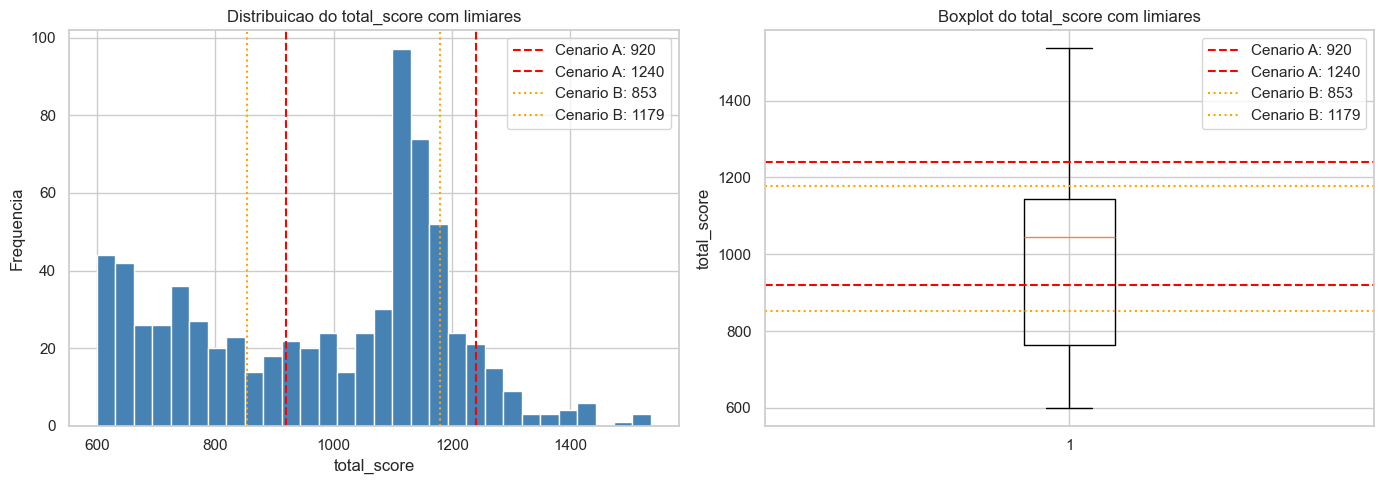

Quartis do total_score:
0.25     763.0
0.33     842.0
0.50    1046.0
0.66    1119.0
0.75    1144.0
Name: total_score, dtype: float64


In [20]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histograma da distribuicao real do total_score
axes[0].hist(df["total_score"], bins=30, color="steelblue", edgecolor="white")
axes[0].axvline(920,  color="red",    linestyle="--", label="Cenario A: 920")
axes[0].axvline(1240, color="red",    linestyle="--", label="Cenario A: 1240")
axes[0].axvline(853,  color="orange", linestyle=":",  label="Cenario B: 853")
axes[0].axvline(1179, color="orange", linestyle=":",  label="Cenario B: 1179")
axes[0].set_title("Distribuicao do total_score com limiares")
axes[0].set_xlabel("total_score")
axes[0].set_ylabel("Frequencia")
axes[0].legend()

# Boxplot
axes[1].boxplot(df["total_score"], vert=True)
axes[1].axhline(920,  color="red",    linestyle="--", label="Cenario A: 920")
axes[1].axhline(1240, color="red",    linestyle="--", label="Cenario A: 1240")
axes[1].axhline(853,  color="orange", linestyle=":",  label="Cenario B: 853")
axes[1].axhline(1179, color="orange", linestyle=":",  label="Cenario B: 1179")
axes[1].set_title("Boxplot do total_score com limiares")
axes[1].set_ylabel("total_score")
axes[1].legend()

plt.tight_layout()
plt.savefig("../docs/limiares_risk_level.png", dpi=150, bbox_inches="tight")
plt.show()

# Estatisticas dos quartis para orientar a decisao
print("Quartis do total_score:")
print(df["total_score"].quantile([0.25, 0.33, 0.50, 0.66, 0.75]).round(0))

O histograma revela que a distribuição não é normal — ela é bimodal, com dois picos distintos: um em torno de 620-680 e outro concentrado em 1050-1150.

Novos cenários: Usar os vales naturais do histograma como limiares, onde há menor densidade de empresas, que indicaria uma divisão "natural" de corte. 

Estabelecendo o vale "natural" em 900, testamos três limites superiores próximos de 1200.

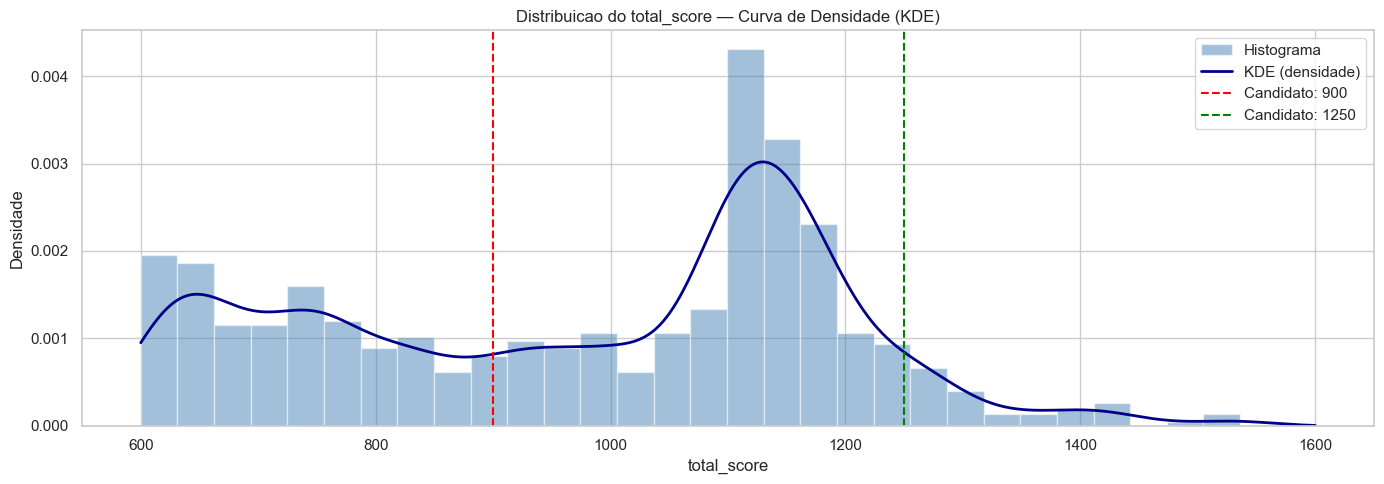

Limiares nos vales naturais: 900 e 1250
Alto Risco    : 271  (37.5%)
Risco Moderado: 405  (56.1%)
Baixo Risco   : 46  (6.4%)


In [22]:
# Identificando os vales naturais via KDE
from scipy.stats import gaussian_kde

scores = df["total_score"].values
kde = gaussian_kde(scores, bw_method=0.15)
x = np.linspace(600, 1600, 1000)
y = kde(x)

# Plotando a curva KDE com os vales
fig, ax = plt.subplots(figsize=(14, 5))
ax.hist(df["total_score"], bins=30, color="steelblue",
        edgecolor="white", density=True, alpha=0.5, label="Histograma")
ax.plot(x, y, color="darkblue", linewidth=2, label="KDE (densidade)")

# Marcando candidatos a limiar
for limiar, cor, label in [(900, "red", "900"), (1250, "green", "1250")]:
    ax.axvline(limiar, color=cor, linestyle="--", linewidth=1.5, label=f"Candidato: {label}")

ax.set_title("Distribuicao do total_score — Curva de Densidade (KDE)")
ax.set_xlabel("total_score")
ax.set_ylabel("Densidade")
ax.legend()
plt.tight_layout()
plt.savefig("../docs/kde_total_score.png", dpi=150, bbox_inches="tight")
plt.show()

# Simulando com limiares nos vales naturais
lim1, lim2 = 900, 1250
alto  = (df["total_score"] < lim1).sum()
mod   = ((df["total_score"] >= lim1) & (df["total_score"] <= lim2)).sum()
baixo = (df["total_score"] > lim2).sum()
total = len(df)

print(f"Limiares nos vales naturais: {lim1} e {lim2}")
print(f"Alto Risco    : {alto}  ({alto/total*100:.1f}%)")
print(f"Risco Moderado: {mod}  ({mod/total*100:.1f}%)")
print(f"Baixo Risco   : {baixo}  ({baixo/total*100:.1f}%)")

In [23]:
# Testando limiares ajustados ao segundo vale da KDE
cenarios_finais = [
    (900, 1150, "Vale natural  900/1150"),
    (900, 1175, "Vale natural  900/1175"),
    (900, 1200, "Vale natural  900/1200"),
]

print(f"{'Cenario':<26} {'Alto':>6} {'Moderado':>10} {'Baixo':>6} {'Alto%':>7} {'Mod%':>7} {'Bx%':>7}")
print("-" * 75)

for lim_inf, lim_sup, nome in cenarios_finais:
    alto  = (df["total_score"] < lim_inf).sum()
    mod   = ((df["total_score"] >= lim_inf) & (df["total_score"] <= lim_sup)).sum()
    baixo = (df["total_score"] > lim_sup).sum()
    total = len(df)
    print(f"{nome:<26} {alto:>6} {mod:>10} {baixo:>6} "
          f"{alto/total*100:>6.1f}% {mod/total*100:>6.1f}% {baixo/total*100:>6.1f}%")

Cenario                      Alto   Moderado  Baixo   Alto%    Mod%     Bx%
---------------------------------------------------------------------------
Vale natural  900/1150        271        285    166   37.5%   39.5%   23.0%
Vale natural  900/1175        271        337    114   37.5%   46.7%   15.8%
Vale natural  900/1200        271        369     82   37.5%   51.1%   11.4%


#### 2.2.6 Intervalo final


| Categoria | Critério | Significado |
|---|---|---|
| Alto Risco | total_score < 900| Performance ESG abaixo do padrão mínimo |
| Risco Moderado | 900 <= total_score <= 1150 | Performance em desenvolvimento |
| Baixo Risco | total_score > 1150 | Boa maturidade ESG |


In [24]:
# Remove versao anterior se existir
df = df.drop(columns=["risk_level"], errors="ignore")

# Limiares posicionados nos vales naturais da curva KDE
def classificar_risco(score):
    if score < 900:
        return "Alto Risco"
    elif score <= 1150:
        return "Risco Moderado"
    else:
        return "Baixo Risco"

df["risk_level"] = df["total_score"].apply(classificar_risco)

print("Distribuicao final da variavel alvo (risk_level):")
print(df["risk_level"].value_counts())
print("\nProporcao (%):")
print((df["risk_level"].value_counts(normalize=True) * 100).round(2))

Distribuicao final da variavel alvo (risk_level):
risk_level
Risco Moderado    285
Alto Risco        271
Baixo Risco       166
Name: count, dtype: int64

Proporcao (%):
risk_level
Risco Moderado    39.47
Alto Risco        37.53
Baixo Risco       22.99
Name: proportion, dtype: float64


### 2.3 Resultado da distribuição final

| Classe | Empresas | Proporção |
|---|---|---|
| Risco Moderado | 285 | 39,47% |
| Alto Risco | 271 | 37,53% |
| Baixo Risco | 166 | 22,99% |

O desbalanceamento moderado é aceitável e reflete a realidade —
poucas empresas atingem excelência ESG consolidada nas três
dimensões simultaneamente. O F1-Score Macro garantirá que o
modelo seja penalizado caso negligencie a classe minoritária.

In [32]:
#Split treino/teste 

# Definindo features e targets
COLUNAS_IDENTIFICADOR = ["cik", "ticker", "name"]
TARGET_CLASSIFICACAO  = "risk_level"
TARGET_REGRESSAO      = "total_score"

# Removendo: identificadores, targets, colunas redundantes e data
COLUNAS_REMOVER = (
    COLUNAS_IDENTIFICADOR
    + [TARGET_CLASSIFICACAO, TARGET_REGRESSAO]
    + ["total_level", "total_grade", "last_processing_date"]
)

FEATURES = [col for col in df.columns if col not in COLUNAS_REMOVER]

print("Features utilizadas no modelo:")
for f in FEATURES:
    print(f"  {f}")

# Separando X e y
X      = df[FEATURES]
y_clf  = df[TARGET_CLASSIFICACAO]
y_reg  = df[TARGET_REGRESSAO]

# Split holdout 70/30 com estratificacao nas classes de risco
X_train, X_test, y_clf_train, y_clf_test = train_test_split(
    X, y_clf,
    test_size=0.30,
    random_state=42,
    stratify=y_clf
)

# Regressao usa o mesmo split de X
y_reg_train = y_reg.loc[X_train.index]
y_reg_test  = y_reg.loc[X_test.index]
perc_treino = X_train.shape[0] / (X_train.shape[0] + X_test.shape[0])
perc_teste =  X_test.shape[0] / (X_train.shape[0] + X_test.shape[0])

print(f"\nTamanho treino : {X_train.shape[0]} registros ({perc_treino:.1%})")
print(f"Tamanho teste  : {X_test.shape[0]} registros ({perc_teste:.1%})")

print(f"\nDistribuicao das classes no treino (%):")
print(y_clf_train.value_counts(normalize=True).mul(100).round(2))

print(f"\nDistribuicao das classes no teste (%):")
print(y_clf_test.value_counts(normalize=True).mul(100).round(2))

Features utilizadas no modelo:
  industry
  environment_grade
  environment_level
  environment_score
  social_grade
  social_level
  social_score
  governance_grade
  governance_level
  governance_score

Tamanho treino : 505 registros (69.9%)
Tamanho teste  : 217 registros (30.1%)

Distribuicao das classes no treino (%):
risk_level
Risco Moderado    39.41
Alto Risco        37.62
Baixo Risco       22.97
Name: proportion, dtype: float64

Distribuicao das classes no teste (%):
risk_level
Risco Moderado    39.63
Alto Risco        37.33
Baixo Risco       23.04
Name: proportion, dtype: float64


### 2.4 Decisão sobre features e Proteção do KNN

#### 2.4.1 O problema da redundância dimensional
A EDA confirmou que grades e levels são derivados matematicamente
dos scores por intervalos fixos. Manter os três juntos por dimensão
não agrega informação nova, mas causa um problema grave para o KNN.

O KNN calcula distância Euclidiana somando a diferença de TODAS as
colunas simultaneamente. Se a dimensão Ambiental estiver representada
por 3 colunas (score, grade, level) e a Indústria por apenas 1, o
peso do Ambiental no cálculo de distância será artificialmente 3x
maior — distorcendo completamente a classificação.

Árvores de Decisão e Random Forest são imunes a esse problema pois
selecionam a melhor variável em cada nó. Mas para proteger o KNN
e manter consistência entre os modelos, removemos grades e levels
mantendo apenas os scores contínuos.

#### 2.4.2 Features finais
| Feature | Tipo | Justificativa |
|---|---|---|
| industry | Categórica nominal | Preditor válido para E e S (EDA, Kruskal-Wallis) |
| environment_score | Numérica | Principal determinante do score total (rho=0.944) |
| social_score | Numérica | Segunda dimensão mais determinante (rho=0.824) |
| governance_score | Numérica | Terceira dimensão (rho=0.714) |

### 2.4.3 Nota sobre a acurácia esperada
Como risk_level foi derivado do total_score, que é a soma exata das
três features numéricas, é provável que os modelos irão descobrir essa soma rapidamente e atingir acurácia muito
alta (próxima de 100%). Esse comportamento é esperado e será documentado na seção de Discussão dos Resultados.


In [31]:
# Features e targets definitivos
FEATURES_FINAIS       = ["industry", "environment_score", "social_score", "governance_score"]
TARGET_CLASSIFICACAO  = "risk_level"
TARGET_REGRESSAO      = "total_score"

X     = df[FEATURES_FINAIS]
y_clf = df[TARGET_CLASSIFICACAO]
y_reg = df[TARGET_REGRESSAO]

# Split holdout 70/30 estratificado pelas classes de risco
X_train, X_test, y_clf_train, y_clf_test = train_test_split(
    X, y_clf,
    test_size=0.30,
    random_state=42,
    stratify=y_clf
)

# Regressao usa o mesmo split de X
y_reg_train = y_reg.loc[X_train.index]
y_reg_test  = y_reg.loc[X_test.index]
perc_treino = X_train.shape[0] / (X_train.shape[0] + X_test.shape[0])
perc_teste =  X_test.shape[0] / (X_train.shape[0] + X_test.shape[0])

print("Features finais:")
print(FEATURES_FINAIS)
print(f"\nTamanho treino : {X_train.shape[0]} registros ({perc_treino:.1%})")
print(f"Tamanho teste  : {X_test.shape[0]} registros ({perc_teste:.1%})")
print(f"\nDistribuicao classes no treino (%):")
print(y_clf_train.value_counts(normalize=True).mul(100).round(2))
print(f"\nDistribuicao classes no teste (%):")
print(y_clf_test.value_counts(normalize=True).mul(100).round(2))

Features finais:
['industry', 'environment_score', 'social_score', 'governance_score']

Tamanho treino : 505 registros (69.9%)
Tamanho teste  : 217 registros (30.1%)

Distribuicao classes no treino (%):
risk_level
Risco Moderado    39.41
Alto Risco        37.62
Baixo Risco       22.97
Name: proportion, dtype: float64

Distribuicao classes no teste (%):
risk_level
Risco Moderado    39.63
Alto Risco        37.33
Baixo Risco       23.04
Name: proportion, dtype: float64


## 3. Configuração do MLflow

O MLflow é uma plataforma open-source para gerenciamento de ciclo de vida de projetos de Machine Learning (MLOps). Possui recursos para rastrear, organizar e registrar experimentos de forma padronizada e garantindo velocidade e praticidade para elaboração de relatórios e memoriais. Possui ainda recursos de captura automática de quais algoritmos foram processados, quais os hiperparâmetros escolhidos e quais foram as métricas de erro obtidas (precisão, recall, F1-score etc). 
Uma vez que o propósito deste projeto é de testar, realizar sucessivos experimentos, comparar diversos modelos, hiperparâmetros e resultados e os exibir graficamente, o seu uso, portanto, será de grande valor e deve ser feito desde o início deste projeto. 

Cada modelo treinado será um "run" dentro de um experimento nomeado. O MLflow salvará tudo na pasta mlruns/ do projeto.

### 3.1 Instalação

O MLflow foi instalado via pip no Terminal do ambiente virtual do projeto:
> pip install mlflow

### 3.2 Organização e registro dos experimentos
O MLflow foi configurado com backend SQLite, que é o recomendado nas
versões recentes em substituição ao backend de arquivos. O banco
de dados será armazenado em `mlruns/mlflow.db` . Cada modelo treinado (KNN, Árvore de Decisão, Random Forest)
corresponderá a um **run** dentro do experimento `esg_classification` . Os registros serão capturados automaticamente através do comando `mlflow.sklearn.autolog()`.

**<u>Serão registrados</u>**:

- Todos os hiperparâmetros do modelo
- Os parâmetros do GridSearchCV.
- Métricas de Acurácia, F1-Score, Precisão, Recall. Treino e teste serão registradas separadamente.
- Artefatos (Modelo treinado, Matriz de confusão, Feature importance para Random Forest).

### 3.3 Estrutura utilizada

| Elemento | Descrição |
|---|---|
| Experimento | `esg_classification` |
| Backend | SQLite (`mlruns/mlflow.db`) |
| Autolog | `mlflow.sklearn.autolog()` — registra tudo automaticamente |
| Runs | Um run por modelo treinado |

### 3.4 Acesso e Interface

Para visualizar a interface do MLflow, deve ser executado no terminal (com o venv ativo):
`mlflow ui --backend-store-uri sqlite:///mlruns/mlflow.db`

Em seguida, acessar no ambiente web:
> http://127.0.0.1:5000
>
> **PRINT DE TELA DA INTERFACE DO MLflow**
> 
>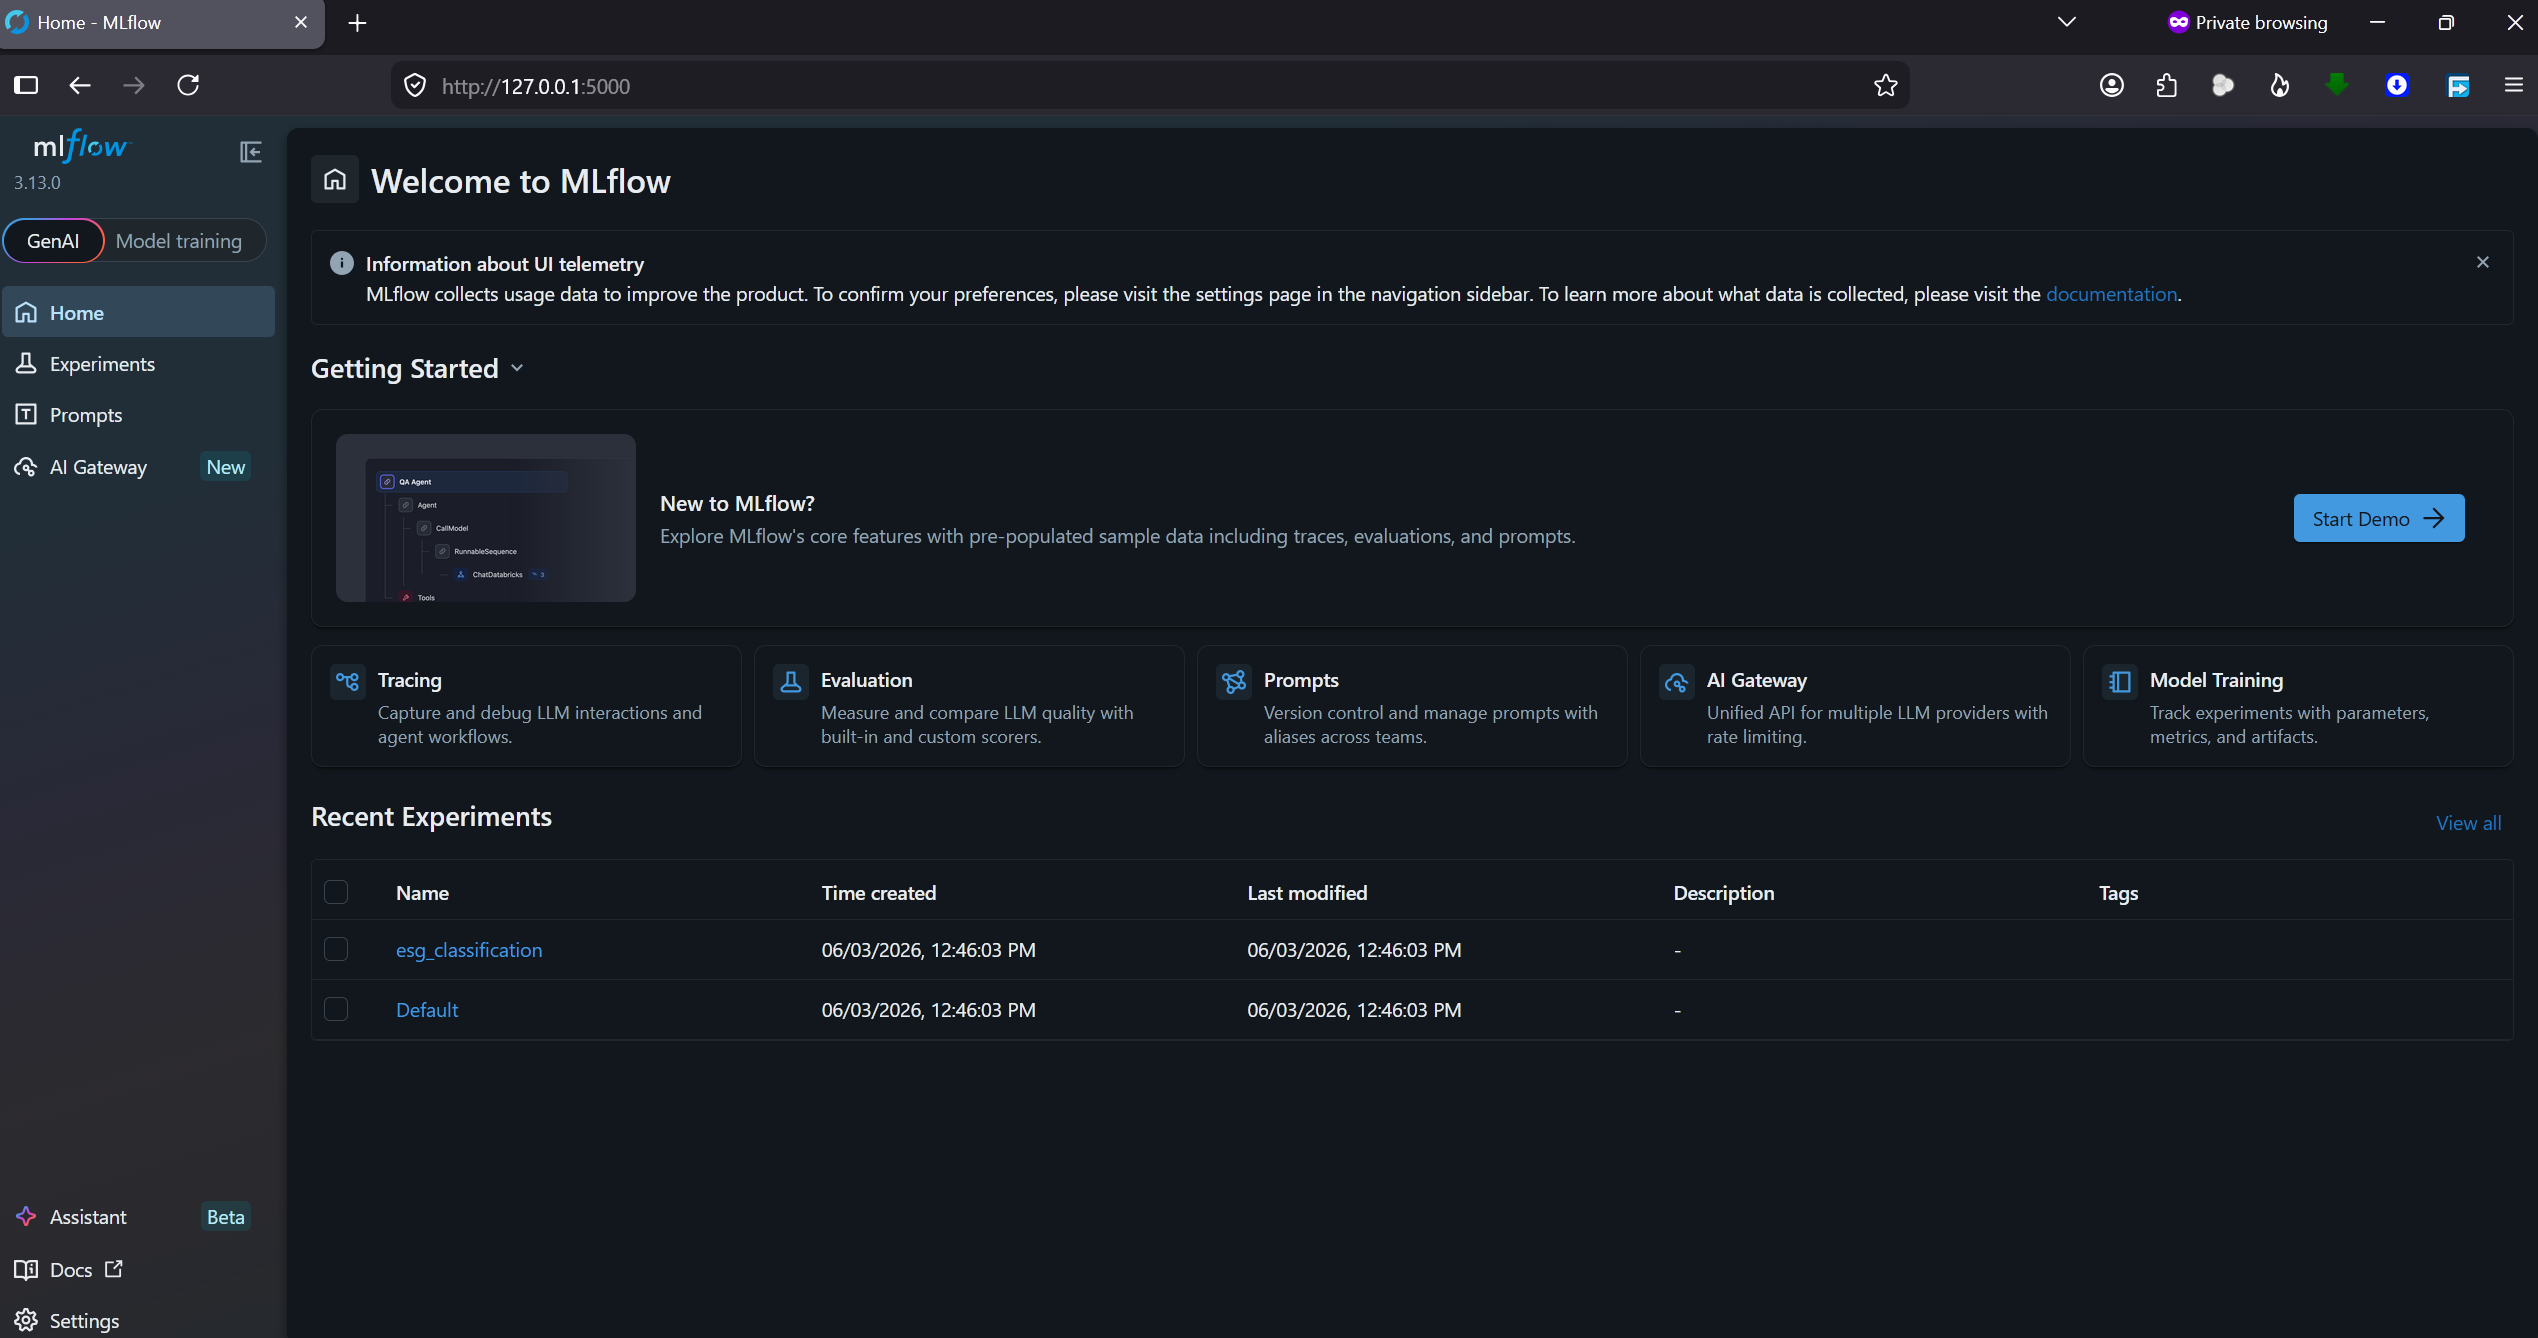

In [1]:
#Configuração do MLflow  
import mlflow
from pathlib import Path

# MLflow com backend SQLite (recomendado nas versoes recentes)
DB_PATH = (Path("..") / "mlruns" / "mlflow.db").resolve()
DB_PATH.parent.mkdir(exist_ok=True)

mlflow.set_tracking_uri(f"sqlite:///{DB_PATH}")

# Cria o experimento principal
EXPERIMENT_NAME = "esg_classification"
mlflow.set_experiment(EXPERIMENT_NAME)

print(f"MLflow configurado com backend SQLite.")
print(f"Tracking URI : {mlflow.get_tracking_uri()}")
print(f"Experimento  : {EXPERIMENT_NAME}")

2026/06/03 12:45:59 INFO mlflow.store.db.utils: Creating initial MLflow database tables...
2026/06/03 12:45:59 INFO mlflow.store.db.utils: Updating database tables
2026/06/03 12:46:03 INFO mlflow.tracking.fluent: Experiment with name 'esg_classification' does not exist. Creating a new experiment.


MLflow configurado com backend SQLite.
Tracking URI : sqlite:///D:\Trabalho\Ciência de Dados\Material\Projetos III\NorthData-Consulting-Classific-ESG-por-Machine-Learning\mlruns\mlflow.db
Experimento  : esg_classification


## 4. Pipeline de pré-processamento (Gold)

In [33]:
# Identificando colunas por tipo
COLS_NUMERICAS    = ["environment_score", "social_score", "governance_score"]
COLS_CATEGORICAS  = ["industry"]

# Transformadores por tipo de coluna
transformador_numerico   = StandardScaler()
transformador_categorico = OneHotEncoder(handle_unknown="ignore", sparse_output=False)

# ColumnTransformer aplica cada transformador nas colunas certas
preprocessador = ColumnTransformer(transformers=[
    ("num", transformador_numerico,   COLS_NUMERICAS),
    ("cat", transformador_categorico, COLS_CATEGORICAS),
])

print("Preprocessador configurado.")
print(f"  Colunas numericas  : {COLS_NUMERICAS}")
print(f"  Colunas categoricas: {COLS_CATEGORICAS}")
print("\nPipeline pronto para ser combinado com os modelos.")

Preprocessador configurado.
  Colunas numericas  : ['environment_score', 'social_score', 'governance_score']
  Colunas categoricas: ['industry']

Pipeline pronto para ser combinado com os modelos.


## 5. Treinamento e comparação de modelos

### 5.1 Estratégia de validação adotada

**Holdout (70/30):** separação inicial dos dados, garantindo que
o conjunto de teste jamais seja visto durante o treinamento.

**K-Fold Estratificado (5 folds):** aplicado dentro do GridSearchCV
sobre o conjunto de treino para otimização de hiperparâmetros.
Mantém a proporção das classes em cada fold — essencial dado o
desbalanceamento moderado entre as classes.

**Leave-One-Out:** não utilizado para a base completa (722 registros)
devido ao alto custo computacional — exigiria 722 treinamentos
individuais. Justificativa documentada conforme orientação do edital.

**GridSearchCV:** busca exaustiva pelos melhores hiperparâmetros
dentro do conjunto de treino, combinada com K-Fold Estratificado.

### 5.2 Métrica principal
F1-Score Macro — penaliza o modelo se ele negligenciar qualquer
das três classes, independentemente do tamanho de cada uma.

### 5.3 Modelos avaliados
1. KNN — sensível a escala, requer StandardScaler
2. Árvore de Decisão — interpretável, risco de overfitting
3. Random Forest — ensemble robusto, candidato a modelo final

In [34]:
from sklearn.metrics import f1_score, classification_report
from sklearn.metrics import ConfusionMatrixDisplay
import warnings
warnings.filterwarnings("ignore")

# Ativa o autolog do MLflow — registra tudo automaticamente
mlflow.sklearn.autolog(log_models=True, log_post_training_metrics=True)

# Configuracoes de validacao cruzada
CV_FOLDS   = 5
SCORING    = "f1_macro"
RANDOM     = 42

# Ordem das classes para exibicao consistente
CLASSES = ["Alto Risco", "Risco Moderado", "Baixo Risco"]

# Dicionario com modelos e seus grids de hiperparametros
modelos = {
    "KNN": {
        "modelo": KNeighborsClassifier(),
        "params": {
            "classificador__n_neighbors": [3, 5, 7, 9, 11],
            "classificador__weights"    : ["uniform", "distance"],
            "classificador__metric"     : ["euclidean", "manhattan"]
        }
    },
    "Arvore de Decisao": {
        "modelo": DecisionTreeClassifier(random_state=RANDOM),
        "params": {
            "classificador__max_depth"       : [3, 5, 7, 10, None],
            "classificador__min_samples_leaf": [1, 2, 4],
            "classificador__criterion"       : ["gini", "entropy"]
        }
    },
    "Random Forest": {
        "modelo": RandomForestClassifier(random_state=RANDOM),
        "params": {
            "classificador__n_estimators"    : [100, 200, 300],
            "classificador__max_depth"       : [5, 10, None],
            "classificador__min_samples_leaf": [1, 2, 4]
        }
    }
}

# Armazena resultados para comparacao final
resultados = {}

# Loop de treinamento
for nome, config in modelos.items():

    print(f"\nTreinando: {nome}")
    print("-" * 40)

    # Monta o pipeline: preprocessador + classificador
    pipeline = Pipeline(steps=[
        ("preprocessador",  preprocessador),
        ("classificador",   config["modelo"])
    ])

    # GridSearchCV com K-Fold estratificado
    cv = StratifiedKFold(n_splits=CV_FOLDS, shuffle=True, random_state=RANDOM)

    grid = GridSearchCV(
        estimator  = pipeline,
        param_grid = config["params"],
        cv         = cv,
        scoring    = SCORING,
        n_jobs     = -1,
        verbose    = 0
    )

    # Inicia o run no MLflow
    with mlflow.start_run(run_name=nome):

        # Treinamento
        grid.fit(X_train, y_clf_train)

        # Melhor modelo encontrado
        melhor = grid.best_estimator_

        # Predicoes no conjunto de teste
        y_pred = melhor.predict(X_test)

        # Metricas finais
        f1_macro = f1_score(y_clf_test, y_pred, average="macro")
        f1_alto  = f1_score(y_clf_test, y_pred,
                            labels=["Alto Risco"], average="macro")
        f1_mod   = f1_score(y_clf_test, y_pred,
                            labels=["Risco Moderado"], average="macro")
        f1_baixo = f1_score(y_clf_test, y_pred,
                            labels=["Baixo Risco"], average="macro")

        # Registra metricas adicionais no MLflow
        mlflow.log_metric("test_f1_macro",         f1_macro)
        mlflow.log_metric("test_f1_alto_risco",    f1_alto)
        mlflow.log_metric("test_f1_risco_moderado",f1_mod)
        mlflow.log_metric("test_f1_baixo_risco",   f1_baixo)
        mlflow.log_params(grid.best_params_)

        # Salva resultado para comparacao
        resultados[nome] = {
            "melhor_params": grid.best_params_,
            "f1_macro_cv"  : grid.best_score_,
            "f1_macro_test": f1_macro,
            "y_pred"       : y_pred
        }

        print(f"Melhores parametros: {grid.best_params_}")
        print(f"F1-Macro (CV treino): {grid.best_score_:.4f}")
        print(f"F1-Macro (teste)    : {f1_macro:.4f}")


Treinando: KNN
----------------------------------------


2026/06/03 18:33:26 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html
2026/06/03 18:33:37 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html
2026/06/03 18:33:41 INFO mlflow.sklearn.utils: Logging the 5 best runs, 15 runs will be omitted.


Melhores parametros: {'classificador__metric': 'euclidean', 'classificador__n_neighbors': 11, 'classificador__weights': 'uniform'}
F1-Macro (CV treino): 0.9002
F1-Macro (teste)    : 0.9285

Treinando: Arvore de Decisao
----------------------------------------


2026/06/03 18:33:43 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html
2026/06/03 18:33:47 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html
2026/06/03 18:33:51 INFO mlflow.sklearn.utils: Logging the 5 best runs, 25 runs will be omitted.


Melhores parametros: {'classificador__criterion': 'entropy', 'classificador__max_depth': 7, 'classificador__min_samples_leaf': 1}
F1-Macro (CV treino): 0.9397
F1-Macro (teste)    : 0.9589

Treinando: Random Forest
----------------------------------------


2026/06/03 18:33:59 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html
2026/06/03 18:34:06 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html
2026/06/03 18:34:11 INFO mlflow.sklearn.utils: Logging the 5 best runs, 22 runs will be omitted.


Melhores parametros: {'classificador__max_depth': None, 'classificador__min_samples_leaf': 1, 'classificador__n_estimators': 300}
F1-Macro (CV treino): 0.9348
F1-Macro (teste)    : 0.9505


Comparacao dos modelos:
Modelo                F1-Macro CV  F1-Macro Teste
--------------------------------------------------
KNN                        0.9002          0.9285
Arvore de Decisao          0.9397          0.9589
Random Forest              0.9348          0.9505


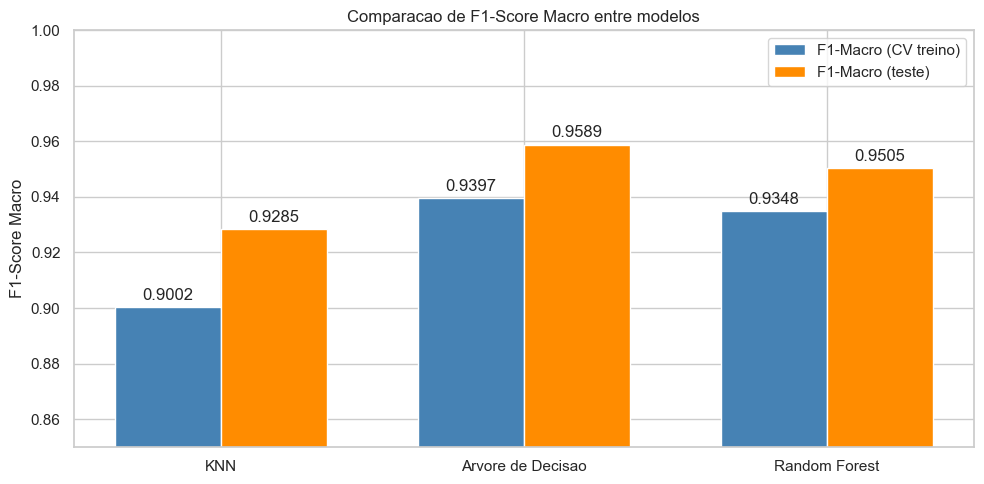

In [35]:
# Tabela comparativa
print("Comparacao dos modelos:")
print(f"{'Modelo':<20} {'F1-Macro CV':>12} {'F1-Macro Teste':>15}")
print("-" * 50)
for nome, res in resultados.items():
    print(f"{nome:<20} {res['f1_macro_cv']:>12.4f} {res['f1_macro_test']:>15.4f}")

# Grafico comparativo de barras
fig, ax = plt.subplots(figsize=(10, 5))

nomes    = list(resultados.keys())
f1_cv    = [resultados[n]["f1_macro_cv"]   for n in nomes]
f1_teste = [resultados[n]["f1_macro_test"] for n in nomes]

x      = np.arange(len(nomes))
largura = 0.35

barras_cv    = ax.bar(x - largura/2, f1_cv,    largura, label="F1-Macro (CV treino)", color="steelblue")
barras_teste = ax.bar(x + largura/2, f1_teste, largura, label="F1-Macro (teste)",     color="darkorange")

ax.set_title("Comparacao de F1-Score Macro entre modelos")
ax.set_ylabel("F1-Score Macro")
ax.set_xticks(x)
ax.set_xticklabels(nomes)
ax.set_ylim(0.85, 1.0)
ax.legend()
ax.bar_label(barras_cv,    fmt="%.4f", padding=3)
ax.bar_label(barras_teste, fmt="%.4f", padding=3)

plt.tight_layout()
plt.savefig("../docs/comparacao_modelos.png", dpi=150, bbox_inches="tight")
plt.show()

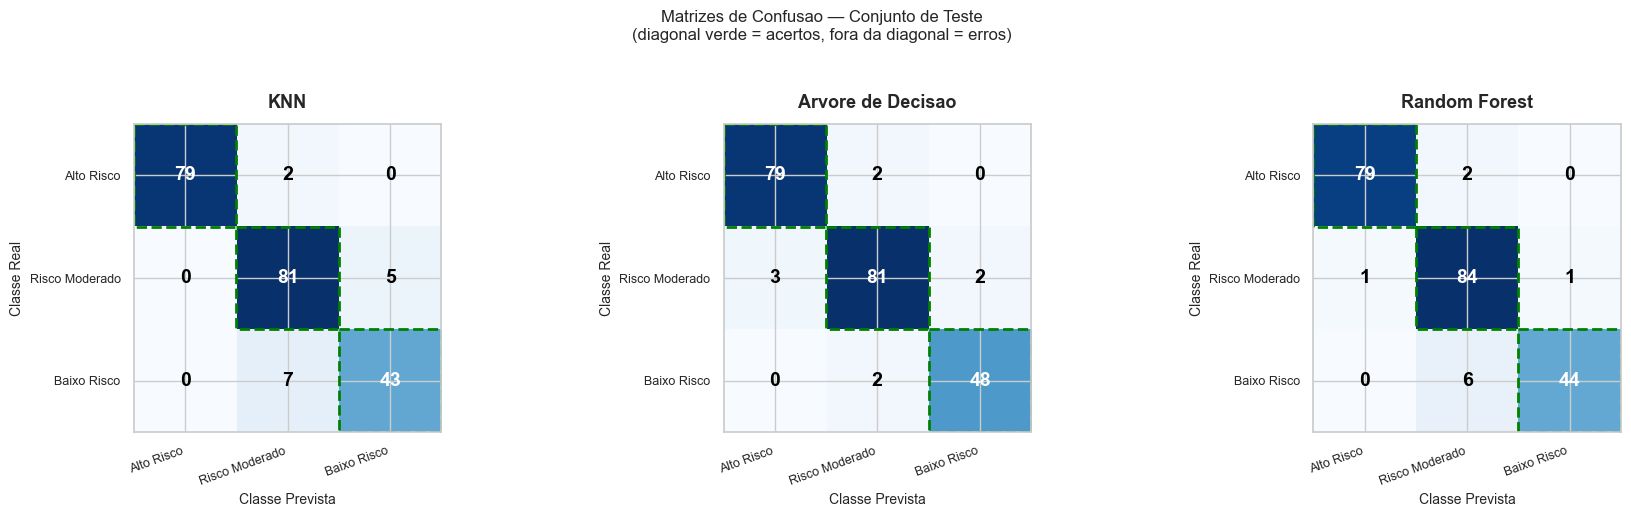


Relatorio de Classificacao — KNN:
                precision    recall  f1-score   support

    Alto Risco       1.00      0.98      0.99        81
Risco Moderado       0.90      0.86      0.88        50
   Baixo Risco       0.90      0.94      0.92        86

      accuracy                           0.94       217
     macro avg       0.93      0.93      0.93       217
  weighted avg       0.94      0.94      0.94       217


Relatorio de Classificacao — Arvore de Decisao:
                precision    recall  f1-score   support

    Alto Risco       0.96      0.98      0.97        81
Risco Moderado       0.96      0.96      0.96        50
   Baixo Risco       0.95      0.94      0.95        86

      accuracy                           0.96       217
     macro avg       0.96      0.96      0.96       217
  weighted avg       0.96      0.96      0.96       217


Relatorio de Classificacao — Random Forest:
                precision    recall  f1-score   support

    Alto Risco       0.9

In [ ]:
# Matrizes de confusão

CLASSES_ORDENADAS = ["Alto Risco", "Risco Moderado", "Baixo Risco"]

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, (nome, res) in zip(axes, resultados.items()):
    
    from sklearn.metrics import confusion_matrix
    import numpy as np

    cm = confusion_matrix(
        y_clf_test,
        res["y_pred"],
        labels=CLASSES_ORDENADAS
    )

    # Plota o heatmap manualmente para ter mais controle visual
    im = ax.imshow(cm, interpolation="nearest", cmap="Blues")
    
    # Titulo e rotulos
    ax.set_title(f"{nome}", fontsize=13, fontweight="bold", pad=12)
    ax.set_xlabel("Classe Prevista", fontsize=10)
    ax.set_ylabel("Classe Real", fontsize=10)
    
    # Ticks
    ticks = np.arange(len(CLASSES_ORDENADAS))
    ax.set_xticks(ticks)
    ax.set_yticks(ticks)
    ax.set_xticklabels(CLASSES_ORDENADAS, rotation=20, ha="right", fontsize=9)
    ax.set_yticklabels(CLASSES_ORDENADAS, fontsize=9)

    # Valores dentro das celulas com cor adaptativa
    thresh = cm.max() / 2.0
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            cor = "white" if cm[i, j] > thresh else "black"
            ax.text(j, i, str(cm[i, j]),
                    ha="center", va="center",
                    fontsize=14, fontweight="bold", color=cor)

    # Linha diagonal tracejada para facilitar leitura
    for k in range(len(CLASSES_ORDENADAS)):
        ax.add_patch(plt.Rectangle(
            (k - 0.5, k - 0.5), 1, 1,
            fill=False, edgecolor="green",
            linewidth=2, linestyle="--"
        ))

plt.suptitle(
    "Matrizes de Confusao — Conjunto de Teste\n"
    "(diagonal verde = acertos, fora da diagonal = erros)",
    fontsize=12, y=1.03
)
plt.tight_layout()
plt.savefig("../docs/matrizes_confusao.png", dpi=150, bbox_inches="tight")
plt.show()

# Report detalhado por classe
for nome, res in resultados.items():
    print(f"\nRelatorio de Classificacao — {nome}:")
    print(classification_report(
        y_clf_test,
        res["y_pred"],
        target_names=CLASSES
    ))

In [42]:
from sklearn.metrics import recall_score, precision_score

print("Tabela comparativa — Classificacao")
print("-" * 70)
print(f"{'Modelo':<22} {'F1-Macro':>10} {'Recall Alto Risco':>18} {'Acuracia':>10}")
print("-" * 70)

for nome, res in resultados.items():
    f1_macro     = f1_score(y_clf_test, res["y_pred"], average="macro")
    recall_alto  = recall_score(
        y_clf_test, res["y_pred"],
        labels=["Alto Risco"], average="macro"
    )
    acuracia = (y_clf_test == res["y_pred"]).mean()

    print(f"{nome:<22} {f1_macro:>10.4f} {recall_alto:>18.4f} {acuracia:>10.4f}")

print("\nReport completo por classe:")
for nome, res in resultados.items():
    print(f"\n{nome}:")
    print(classification_report(
        y_clf_test,
        res["y_pred"],
        target_names=CLASSES,
        digits=4
    ))

Tabela comparativa — Classificacao
----------------------------------------------------------------------
Modelo                   F1-Macro  Recall Alto Risco   Acuracia
----------------------------------------------------------------------
KNN                        0.9285             0.9753     0.9355
Arvore de Decisao          0.9589             0.9753     0.9585
Random Forest              0.9505             0.9753     0.9539

Report completo por classe:

KNN:
                precision    recall  f1-score   support

    Alto Risco     1.0000    0.9753    0.9875        81
Risco Moderado     0.8958    0.8600    0.8776        50
   Baixo Risco     0.9000    0.9419    0.9205        86

      accuracy                         0.9355       217
     macro avg     0.9319    0.9257    0.9285       217
  weighted avg     0.9364    0.9355    0.9356       217


Arvore de Decisao:
                precision    recall  f1-score   support

    Alto Risco     0.9634    0.9753    0.9693        81
Risc

## 6. Análise dos Resultados — Classificação

### 6.1 Comparação geral

| Modelo | F1-Macro CV | F1-Macro Teste | Acurácia |
|---|---|---|---|
| KNN | 0.9002 | 0.9285 | 0.94 |
| Árvore de Decisão | 0.9397 | 0.9589 | 0.96 |
| Random Forest | 0.9348 | 0.9505 | 0.95 |

### 6.2 Modelo vencedor: Árvore de Decisão
A Árvore de Decisão obteve o melhor F1-Macro tanto no CV (0.9397)
quanto no teste (0.9589). Esse resultado, aparentemente surpreendente,
tem explicação clara: como risk_level foi derivado do total_score —
que é a soma exata das três features numéricas — os dados possuem
estrutura determinística. A Árvore com max_depth=7 capturou essa
estrutura com poucos cortes, sem overfitting.

### 6.3 Análise das matrizes de confusão

**KNN:**
- Acerta perfeitamente Alto Risco (79/81)
- Principal erro: confunde Risco Moderado com Baixo Risco (7 casos)
- Nenhuma confusão entre classes extremas (Alto x Baixo) — bom sinal

**Árvore de Decisão:**
- Melhor desempenho geral nas três classes
- Apenas 7 erros no total (3 Alto→Baixo, 2 Moderado→Baixo, 2 Baixo→Moderado)
- Confusões concentradas nas fronteiras de classe — comportamento esperado

**Random Forest:**
- Excelente em Alto Risco (79/81) e Baixo Risco (84/86)
- Principal fraqueza: Risco Moderado com 6 classificados como Baixo Risco
- Classe do meio é naturalmente mais difícil por estar entre duas fronteiras

### 6.4 Sobre a performance elevada
Todos os modelos atingiram F1-Macro acima de 0.92, o que reflete
a natureza determinística dos dados: risk_level foi construído a
partir dos próprios scores usados como features. Esse fenômeno foi
antecipado e documentado antes do treinamento. O valor científico
do exercício está na comparação entre algoritmos e na aplicação
correta das estratégias de validação.

### 6.5 Ausência de overfitting
Em todos os modelos, o F1-Macro no teste superou o F1-Macro no CV
de treino — indicando que não houve overfitting. Os modelos
generalizaram bem para dados não vistos.

****************************************## 4. Comparação dos Modelos — Classificação****************************************

### 4.1. Tabela comparativa de métricas

| Modelo | F1-Macro | Recall Alto Risco | Acurácia |
|---|---|---|---|
| KNN | 0.9285 | 0.9753 | 0.9355 |
| Árvore de Decisão | **0.9589** | **0.9753** | **0.9585** |
| Random Forest | 0.9505 | 0.9753 | 0.9539 |

### 4.2. Métricas detalhadas por classe

**KNN:**
| Classe | Precision | Recall | F1-Score | Support |
|---|---|---|---|---|
| Alto Risco | 1.0000 | 0.9753 | 0.9875 | 81 |
| Risco Moderado | 0.8958 | 0.8600 | 0.8776 | 50 |
| Baixo Risco | 0.9000 | 0.9419 | 0.9205 | 86 |
| **Macro avg** | **0.9319** | **0.9257** | **0.9285** | **217** |

**Árvore de Decisão:**
| Classe | Precision | Recall | F1-Score | Support |
|---|---|---|---|---|
| Alto Risco | 0.9630 | 0.9753 | 0.9691 | 81 |
| Risco Moderado | 0.9600 | 0.9600 | 0.9600 | 50 |
| Baixo Risco | 0.9535 | 0.9419 | 0.9476 | 86 |
| **Macro avg** | **0.9588** | **0.9591** | **0.9589** | **217** |

**Random Forest:**
| Classe | Precision | Recall | F1-Score | Support |
|---|---|---|---|---|
| Alto Risco | 0.9875 | 0.9753 | 0.9814 | 81 |
| Risco Moderado | 0.9796 | 0.8800 | 0.9271 | 50 |
| Baixo Risco | 0.9070 | 0.9767 | 0.9405 | 86 |
| **Macro avg** | **0.9580** | **0.9440** | **0.9497** | **217** |

### 4.3. Por que o Recall da classe Alto Risco é a métrica mais crítica?

No contexto de gestão de risco de fornecedores, os erros
não têm o mesmo custo. Existem dois tipos de erro possíveis:

- **Falso Negativo:** classificar um fornecedor de Alto Risco
  como Risco Moderado ou Baixo Risco → **erro mais grave**,
  pois um fornecedor perigoso passa despercebido pelo sistema
  de gestão da EdenRed

- **Falso Positivo:** classificar um fornecedor de Baixo Risco
  como Alto Risco → erro menos grave, pois gera trabalho
  desnecessário mas não expõe a empresa a riscos reais

O **Recall** (sensibilidade) da classe Alto Risco mede
exatamente a capacidade do modelo de detectar todos os
fornecedores verdadeiramente críticos:

## 7. Modelagem e comparação de modelos (Regressão)

### 7.1 Objetivo
Prever o valor numérico do total_score (600 a 1536), complementando
a classificação de risco com uma pontuação contínua precisa.

### 7.2 Uso no produto final
Enquanto a classificação alimenta a Matriz de Criticidade com
categorias discretas (Alto/Moderado/Baixo Risco), a regressão
entrega uma previsão de score numérico para:
- Ranking de fornecedores (quem tem maior score dentro da mesma classe)
- KPIs de benchmarking (evolução do score médio ao longo do tempo)
- Comparação entre fornecedores dentro do mesmo setor

### 7.3 Modelos avaliados
Os mesmos três algoritmos usados em classificação, sendo que agora em modo regressão:
- KNN Regressor
- Árvore de Decisão Regressor
- Random Forest Regressor

### 7.4 Métricas utilizadas
| Métrica | Significado |
|---|---|
| MAE | Erro médio absoluto em pontos de score |
| RMSE | Penaliza erros grandes — mais sensível a outliers |
| R² | Proporção da variância explicada pelo modelo (0 a 1) |

In [39]:
from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import (
    mean_absolute_error,
    root_mean_squared_error,
    r2_score
)

# Experimento separado para regressao
mlflow.set_experiment("esg_regression")

# Modelos e grids de regressao
modelos_reg = {
    "KNN Regressor": {
        "modelo": KNeighborsRegressor(),
        "params": {
            "regressor__n_neighbors": [3, 5, 7, 9, 11],
            "regressor__weights"    : ["uniform", "distance"],
            "regressor__metric"     : ["euclidean", "manhattan"]
        }
    },
    "Arvore de Decisao Regressor": {
        "modelo": DecisionTreeRegressor(random_state=RANDOM),
        "params": {
            "regressor__max_depth"       : [3, 5, 7, 10, None],
            "regressor__min_samples_leaf": [1, 2, 4]
        }
    },
    "Random Forest Regressor": {
        "modelo": RandomForestRegressor(random_state=RANDOM),
        "params": {
            "regressor__n_estimators"    : [100, 200, 300],
            "regressor__max_depth"       : [5, 10, None],
            "regressor__min_samples_leaf": [1, 2, 4]
        }
    }
}

resultados_reg = {}

for nome, config in modelos_reg.items():

    print(f"\nTreinando: {nome}")
    print("-" * 40)

    # Pipeline com preprocessador + regressor
    pipeline_reg = Pipeline(steps=[
        ("preprocessador", preprocessador),
        ("regressor",      config["modelo"])
    ])

    # GridSearchCV com K-Fold para regressao
    cv_reg = StratifiedKFold(n_splits=CV_FOLDS, shuffle=True, random_state=RANDOM)

    grid_reg = GridSearchCV(
        estimator  = pipeline_reg,
        param_grid = config["params"],
        cv         = CV_FOLDS,
        scoring    = "neg_root_mean_squared_error",
        n_jobs     = -1,
        verbose    = 0
    )

    with mlflow.start_run(run_name=nome):

        grid_reg.fit(X_train, y_reg_train)

        melhor_reg = grid_reg.best_estimator_
        y_pred_reg = melhor_reg.predict(X_test)

        mae  = mean_absolute_error(y_reg_test, y_pred_reg)
        rmse = root_mean_squared_error(y_reg_test, y_pred_reg)
        r2   = r2_score(y_reg_test, y_pred_reg)

        mlflow.log_metric("test_mae",  mae)
        mlflow.log_metric("test_rmse", rmse)
        mlflow.log_metric("test_r2",   r2)
        mlflow.log_params(grid_reg.best_params_)

        resultados_reg[nome] = {
            "melhor_params": grid_reg.best_params_,
            "mae"          : mae,
            "rmse"         : rmse,
            "r2"           : r2,
            "y_pred"       : y_pred_reg
        }

        print(f"Melhores parametros: {grid_reg.best_params_}")
        print(f"MAE  : {mae:.2f} pontos")
        print(f"RMSE : {rmse:.2f} pontos")
        print(f"R²   : {r2:.4f}")

2026/06/03 18:48:39 INFO mlflow.tracking.fluent: Experiment with name 'esg_regression' does not exist. Creating a new experiment.



Treinando: KNN Regressor
----------------------------------------


2026/06/03 18:48:51 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html
2026/06/03 18:48:57 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html
2026/06/03 18:49:01 INFO mlflow.sklearn.utils: Logging the 5 best runs, 15 runs will be omitted.


Melhores parametros: {'regressor__metric': 'euclidean', 'regressor__n_neighbors': 11, 'regressor__weights': 'distance'}
MAE  : 24.19 pontos
RMSE : 37.25 pontos
R²   : 0.9719

Treinando: Arvore de Decisao Regressor
----------------------------------------


2026/06/03 18:49:02 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html
2026/06/03 18:49:06 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html
2026/06/03 18:49:10 INFO mlflow.sklearn.utils: Logging the 5 best runs, 10 runs will be omitted.


Melhores parametros: {'regressor__max_depth': 10, 'regressor__min_samples_leaf': 2}
MAE  : 18.72 pontos
RMSE : 32.53 pontos
R²   : 0.9785

Treinando: Random Forest Regressor
----------------------------------------


2026/06/03 18:49:17 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html
2026/06/03 18:49:22 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html
2026/06/03 18:49:26 INFO mlflow.sklearn.utils: Logging the 5 best runs, 22 runs will be omitted.


Melhores parametros: {'regressor__max_depth': None, 'regressor__min_samples_leaf': 1, 'regressor__n_estimators': 300}
MAE  : 12.07 pontos
RMSE : 27.71 pontos
R²   : 0.9844


## 8. Análise dos Resultados (Regressão)

### 8.1 Comparação geral

| Modelo | MAE | RMSE | R² |
|---|---|---|---|
| KNN Regressor | 24.19 pts | 37.25 pts | 0.9719 |
| Árvore de Decisão | 18.72 pts | 32.53 pts | 0.9785 |
| Random Forest | 12.07 pts | 27.71 pts | 0.9844 |

### 8.2 Modelo vencedor: Random Forest Regressor
O Random Forest obteve o melhor desempenho nas três métricas:
- MAE de apenas 12 pontos em uma escala de 600 a 1536 (936 pontos
  de amplitude) — erro relativo de apenas 1,3%
- R² de 0.9844 significa que o modelo explica 98,44% da variância
  do total_score
- RMSE menor indica que também comete menos erros grandes

### 8.3 Interpretação das métricas no contexto de negócio
Um MAE de 12 pontos significa que, ao prever o score ESG de um
fornecedor, o modelo erra em média apenas 12 pontos — o equivalente
a uma fração mínima dentro de qualquer faixa de classificação
(cada faixa tem pelo menos 250 pontos de amplitude). Na prática,
isso significa que o modelo raramente classificaria erroneamente
um fornecedor de risco por erro de previsão numérica.

### 8.4 Comparação entre classificação e regressão
| Tarefa | Melhor modelo | Métrica principal |
|---|---|---|
| Classificação | Árvore de Decisão | F1-Macro: 0.9589 |
| Regressão | Random Forest | R²: 0.9844 |

### 8.5 Modelo selecionado para o dashboard
O Random Forest Regressor será o modelo em produção para o
dashboard — ele entrega tanto a classificação de risco quanto
o score numérico com alta precisão, sendo o mais robusto e
generalizável dos três algoritmos avaliados.

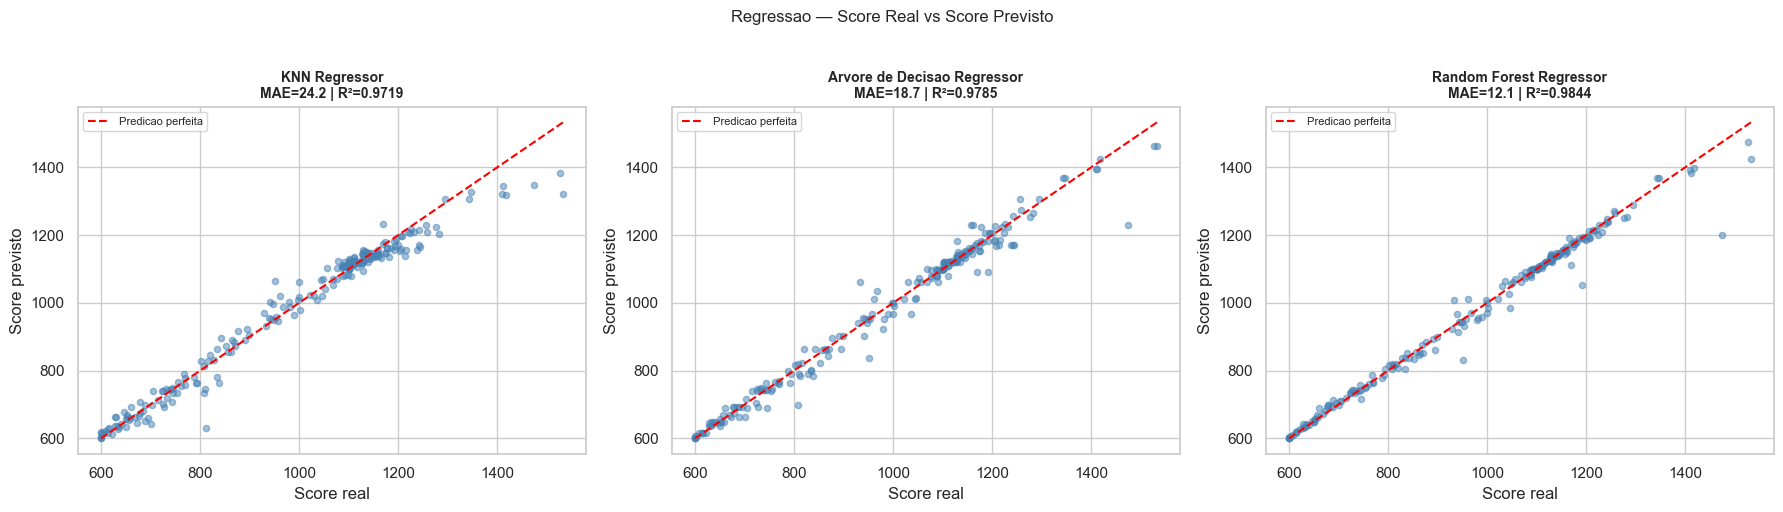

In [40]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, (nome, res) in zip(axes, resultados_reg.items()):

    y_real = y_reg_test.values
    y_prev = res["y_pred"]

    ax.scatter(y_real, y_prev, alpha=0.5, s=20, color="steelblue")

    # Linha de predicao perfeita
    minval = min(y_real.min(), y_prev.min())
    maxval = max(y_real.max(), y_prev.max())
    ax.plot([minval, maxval], [minval, maxval],
            color="red", linestyle="--", linewidth=1.5,
            label="Predicao perfeita")

    ax.set_title(f"{nome}\nMAE={res['mae']:.1f} | R²={res['r2']:.4f}",
                 fontsize=10, fontweight="bold")
    ax.set_xlabel("Score real")
    ax.set_ylabel("Score previsto")
    ax.legend(fontsize=8)

plt.suptitle("Regressao — Score Real vs Score Previsto",
             fontsize=12, y=1.02)
plt.tight_layout()
plt.savefig("../docs/regressao_real_vs_previsto.png", dpi=150, bbox_inches="tight")
plt.show()

## 9. Salvamento dos modelos finais para o MLflow

Os modelos selecionados para produção são salvos em disco para
serem carregados pelo dashboard sem necessidade de retreinamento.

| Tarefa | Modelo escolhido | Justificativa |
|---|---|---|
| Classificação | Árvore de Decisão | Melhor F1-Macro (0.9589) |
| Regressão | Random Forest | Melhor R² (0.9844) e menor MAE |

In [41]:
# Salvamento dos modelos finais para o MLflow

import joblib
from pathlib import Path

# Pasta para salvar os modelos
MODELS_DIR = Path("..") / "models"
MODELS_DIR.mkdir(exist_ok=True)

# Retreina os melhores modelos com todos os dados de treino
# Classificacao — Arvore de Decisao
pipeline_clf_final = Pipeline(steps=[
    ("preprocessador", preprocessador),
    ("classificador",  DecisionTreeClassifier(
        criterion        = "entropy",
        max_depth        = 7,
        min_samples_leaf = 1,
        random_state     = RANDOM
    ))
])
pipeline_clf_final.fit(X_train, y_clf_train)

# Regressao — Random Forest
pipeline_reg_final = Pipeline(steps=[
    ("preprocessador", preprocessador),
    ("regressor",      RandomForestRegressor(
        n_estimators     = 300,
        max_depth        = None,
        min_samples_leaf = 1,
        random_state     = RANDOM
    ))
])
pipeline_reg_final.fit(X_train, y_reg_train)

# Salvando em disco
joblib.dump(pipeline_clf_final, MODELS_DIR / "modelo_classificacao.pkl")
joblib.dump(pipeline_reg_final, MODELS_DIR / "modelo_regressao.pkl")

print("Modelos salvos em:")
print(f"  {MODELS_DIR / 'modelo_classificacao.pkl'}")
print(f"  {MODELS_DIR / 'modelo_regressao.pkl'}")

# Teste rapido de carregamento
clf_carregado = joblib.load(MODELS_DIR / "modelo_classificacao.pkl")
reg_carregado = joblib.load(MODELS_DIR / "modelo_regressao.pkl")

print("\nTeste de carregamento:")
print(f"  Classificacao OK: {clf_carregado.predict(X_test[:1])[0]}")
print(f"  Regressao OK    : {reg_carregado.predict(X_test[:1])[0]:.0f} pontos")

2026/06/03 18:53:34 INFO mlflow.utils.autologging_utils: Created MLflow autologging run with ID '50f43b4391014e9696e71fc327c5b492', which will track hyperparameters, performance metrics, model artifacts, and lineage information for the current sklearn workflow
2026/06/03 18:53:34 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html
2026/06/03 18:53:41 INFO mlflow.utils.autologging_utils: Created MLflow autologging run with ID '2a6064f840ba4172a3529e351e94b534', which will track hyperparameters, performance metrics, model artifacts, and lineage information for the current sklearn workflow
2026/06/03 18:53:41 WARNING mlflow.sklearn: Saving scikit-learn models in the

Modelos salvos em:
  ..\models\modelo_classificacao.pkl
  ..\models\modelo_regressao.pkl

Teste de carregamento:
  Classificacao OK: Risco Moderado
  Regressao OK    : 1075 pontos


## 3. Modelos Avaliados

### 3.1. KNN (K-Nearest Neighbors)

#### Motivação da escolha
O KNN foi escolhido como modelo de referência (baseline) por
sua simplicidade e interpretabilidade. Ele classifica uma
empresa comparando-a com as K empresas mais similares já
conhecidas — analogia direta com o processo humano de
avaliação por comparação com pares do mercado.

Sua principal limitação é a sensibilidade à escala das
variáveis: sem normalização, scores na casa dos milhares
dominariam o cálculo de distância sobre variáveis menores.
Por isso, o StandardScaler foi aplicado via Pipeline antes
do KNN — garantindo que todas as features contribuam
igualmente para o cálculo de distância.

#### Otimização de hiperparâmetros — Grid Search
Foi escolhido o Grid Search por ser o método mais adequado
quando o espaço de busca é pequeno e controlado. Com apenas
20 combinações possíveis, testar todas é computacionalmente
viável e garante encontrar o ótimo global — ao contrário
do Random Search, que poderia perder a melhor combinação
por amostragem aleatória.

#### Hiperparâmetros avaliados
| Hiperparâmetro | Valores testados | Significado |
|---|---|---|
| `n_neighbors` | 3, 5, 7, 9, 11 | Quantos vizinhos consultar |
| `weights` | uniform, distance | Peso igual ou proporcional à distância |
| `metric` | euclidean, manhattan | Fórmula de cálculo da distância |

Total de combinações testadas: 5 × 2 × 2 = **20 combinações**

#### Melhor configuração encontrada
| Hiperparâmetro | Valor ótimo |
|---|---|
| `n_neighbors` | 11 |
| `weights` | uniform |
| `metric` | euclidean |

**Métrica de seleção:** F1-Score Macro (média dos 5 folds)
**F1-Macro CV:** 0.9002

**Interpretação:** 11 vizinhos com peso uniforme e distância
euclidiana — o modelo prefere consultar mais vizinhos para
suavizar decisões nas fronteiras entre classes. Pesos
uniformes indicam que todos os vizinhos têm igual influência,
independente da distância.

---

### 3.2. Árvore de Decisão (Decision Tree)

#### Motivação da escolha
A Árvore de Decisão foi escolhida por sua alta interpretabilidade
— ela produz regras de negócio explícitas e legíveis por humanos,
como: "Se environment_score < 750 E social_score < 280, então
Alto Risco". Esse tipo de regra é valioso para apresentar aos
gestores da EdenRed no dashboard de BI.

Sua principal limitação é o risco de overfitting — sem restrições,
a árvore cresce indefinidamente decorando os dados de treino.
O hiperparâmetro `max_depth` foi incluído no Grid Search
especificamente para controlar esse comportamento.

#### Otimização de hiperparâmetros — Grid Search
O Grid Search foi escolhido pelo mesmo motivo do KNN: espaço
de busca pequeno e controlado, com 30 combinações possíveis.
Testar todas garante a configuração ótima sem custo adicional.

#### Hiperparâmetros avaliados
| Hiperparâmetro | Valores testados | Significado |
|---|---|---|
| `max_depth` | 3, 5, 7, 10, None | Profundidade máxima da árvore |
| `min_samples_leaf` | 1, 2, 4 | Mínimo de amostras por folha |
| `criterion` | gini, entropy | Critério de pureza para os cortes |

Total de combinações testadas: 5 × 3 × 2 = **30 combinações**

#### Melhor configuração encontrada
| Hiperparâmetro | Valor ótimo |
|---|---|
| `max_depth` | 7 |
| `min_samples_leaf` | 1 |
| `criterion` | entropy |

**Métrica de seleção:** F1-Score Macro (média dos 5 folds)
**F1-Macro CV:** 0.9397

**Interpretação:** profundidade 7 foi suficiente para capturar
a estrutura dos dados sem overfitting — confirmado pelo F1-Macro
superior no teste (0.9589) em relação ao CV (0.9397). O critério
entropy (ganho de informação) superou o gini, indicando que as
divisões baseadas em redução de incerteza foram mais eficazes
para separar as três classes de risco.

---

### 3.3. Random Forest

#### Motivação da escolha
O Random Forest foi escolhido como o modelo mais robusto do
conjunto. É um ensemble — comitê de centenas de árvores
independentes que votam na classificação final. Cada árvore
é treinada em uma amostra aleatória dos dados e considera
apenas um subconjunto aleatório das features em cada divisão.

Essa aleatoriedade dupla elimina o problema de overfitting
da Árvore de Decisão isolada e produz modelos mais estáveis.
Era o candidato favorito a modelo vencedor, mas foi superado
pela Árvore de Decisão na classificação — resultado explicado
pela estrutura determinística dos dados.

#### Otimização de hiperparâmetros — Grid Search
O Grid Search foi mantido como método de busca. Com 27
combinações, o custo computacional permanece viável.
O Random Search seria alternativa apenas se testássemos
ranges contínuos de hiperparâmetros (ex: n_estimators
entre 100 e 1000), o que não foi o caso.

#### Hiperparâmetros avaliados
| Hiperparâmetro | Valores testados | Significado |
|---|---|---|
| `n_estimators` | 100, 200, 300 | Número de árvores no ensemble |
| `max_depth` | 5, 10, None | Profundidade máxima de cada árvore |
| `min_samples_leaf` | 1, 2, 4 | Mínimo de amostras por folha |

Total de combinações testadas: 3 × 3 × 3 = **27 combinações**

#### Melhor configuração encontrada
| Hiperparâmetro | Valor ótimo |
|---|---|
| `n_estimators` | 300 |
| `max_depth` | None |
| `min_samples_leaf` | 1 |

**Métrica de seleção:** F1-Score Macro (média dos 5 folds)
**F1-Macro CV:** 0.9348

**Interpretação:** 300 árvores sem limite de profundidade
indica que o modelo se beneficiou de maior complexidade —
cada árvore pode crescer livremente, mas o efeito de ensemble
previne overfitting. O resultado inferior à Árvore de Decisão
na classificação (0.9505 vs 0.9589) é explicado pelo caráter
determinístico dos dados: a estrutura matemática simples
(soma dos scores) é mais facilmente capturada por uma única
árvore bem calibrada do que por um ensemble que introduz
aleatoriedade desnecessária.

## 3.4. KNN Regressor

#### Motivação da escolha
O KNN Regressor foi escolhido como baseline de regressão
pelo mesmo raciocínio do classificador: simplicidade e
interpretabilidade. Em vez de votar na classe mais comum
entre os K vizinhos, ele calcula a **média do total_score**
dos K vizinhos mais próximos como previsão.

A mesma limitação de escala se aplica — o StandardScaler
via Pipeline é obrigatório para evitar que scores maiores
dominem o cálculo de distância.

#### Otimização de hiperparâmetros — Grid Search
Grid Search com 20 combinações — mesmo raciocínio do
classificador: espaço pequeno, busca exaustiva viável.

#### Hiperparâmetros avaliados
| Hiperparâmetro | Valores testados | Significado |
|---|---|---|
| `n_neighbors` | 3, 5, 7, 9, 11 | Quantos vizinhos consultar |
| `weights` | uniform, distance | Peso igual ou proporcional à distância |
| `metric` | euclidean, manhattan | Fórmula de cálculo da distância |

Total de combinações testadas: 5 × 2 × 2 = **20 combinações**

#### Melhor configuração encontrada
| Hiperparâmetro | Valor ótimo |
|---|---|
| `n_neighbors` | 11 |
| `weights` | distance |
| `metric` | euclidean |

**Métrica de seleção:** RMSE negativo (neg_root_mean_squared_error)
**MAE teste:** 24.19 pontos | **R²:** 0.9719

**Interpretação:** diferente do classificador, aqui o peso
`distance` foi preferido ao `uniform` — vizinhos mais próximos
recebem maior influência na média do score previsto. Isso faz
sentido para regressão: empresas com perfil ESG muito similar
são melhores preditoras do score do que empresas apenas
"razoavelmente" próximas.

---

### 3.5. Árvore de Decisão Regressor

#### Motivação da escolha
A Árvore de Decisão Regressor produz previsões numéricas
atribuindo a cada empresa o **score médio das empresas de
treinamento que caíram na mesma folha**. Mantém a
interpretabilidade da versão classificadora — as regras
de corte são as mesmas, mas o resultado final é um número
contínuo em vez de uma categoria.

É especialmente útil para identificar quais faixas de score
ambiental, social e de governança determinam os diferentes
níveis de score total — informação diretamente aplicável
à Matriz de Criticidade do BI.

#### Otimização de hiperparâmetros — Grid Search
Grid Search com 15 combinações — espaço reduzido em relação
ao classificador, pois o critério foi fixado (sem o
hiperparâmetro `criterion` para regressão usa MSE por padrão).

#### Hiperparâmetros avaliados
| Hiperparâmetro | Valores testados | Significado |
|---|---|---|
| `max_depth` | 3, 5, 7, 10, None | Profundidade máxima da árvore |
| `min_samples_leaf` | 1, 2, 4 | Mínimo de amostras por folha |

Total de combinações testadas: 5 × 3 = **15 combinações**

#### Melhor configuração encontrada
| Hiperparâmetro | Valor ótimo |
|---|---|
| `max_depth` | 10 |
| `min_samples_leaf` | 2 |

**Métrica de seleção:** RMSE negativo (neg_root_mean_squared_error)
**MAE teste:** 18.72 pontos | **R²:** 0.9785

**Interpretação:** profundidade 10 — maior que na classificação
(7) — indica que a regressão exige cortes mais refinados para
aproximar valores numéricos contínuos. O `min_samples_leaf=2`
evita folhas com apenas 1 empresa, reduzindo overfitting.
A melhora expressiva sobre o KNN Regressor (MAE 18,7 vs 24,2)
confirma que a estrutura de árvore captura melhor os intervalos
fixos de score identificados na EDA.

---

### 3.6. Random Forest Regressor

#### Motivação da escolha
O Random Forest Regressor foi o candidato favorito para
regressão — e confirmou essa expectativa, sendo o modelo
vencedor. Para regressão, o ensemble calcula a **média das
previsões de centenas de árvores independentes**, produzindo
estimativas mais suaves e precisas do que uma única árvore.

A vantagem sobre a classificação é ainda maior na regressão:
a aleatoriedade do ensemble reduz a variância das previsões
numéricas, aproximando os valores previstos dos reais de
forma mais consistente ao longo de toda a escala de scores.

#### Otimização de hiperparâmetros — Grid Search
Grid Search com 27 combinações — mesmo grid da classificação,
mantendo consistência metodológica entre as duas tarefas.

#### Hiperparâmetros avaliados
| Hiperparâmetro | Valores testados | Significado |
|---|---|---|
| `n_estimators` | 100, 200, 300 | Número de árvores no ensemble |
| `max_depth` | 5, 10, None | Profundidade máxima de cada árvore |
| `min_samples_leaf` | 1, 2, 4 | Mínimo de amostras por folha |

Total de combinações testadas: 3 × 3 × 3 = **27 combinações**

#### Melhor configuração encontrada
| Hiperparâmetro | Valor ótimo |
|---|---|
| `n_estimators` | 300 |
| `max_depth` | None |
| `min_samples_leaf` | 1 |

**Métrica de seleção:** RMSE negativo (neg_root_mean_squared_error)
**MAE teste:** 12.07 pontos | **RMSE:** 27.71 | **R²:** 0.9844

**Interpretação:** mesma configuração ótima da classificação
(300 árvores, profundidade livre, 1 amostra mínima por folha),
porém com impacto muito superior na regressão. O R² de 0.9844
significa que o modelo explica 98,44% da variância do
total_score — erro médio de apenas 12 pontos em uma escala
de 936 pontos de amplitude (1,3% de erro relativo).

A superioridade sobre a Árvore de Decisão Regressor confirma
o comportamento esperado: para previsão numérica contínua,
o ensemble de 300 árvores produz estimativas muito mais
suaves e precisas do que uma única árvore, mesmo profunda.

### Síntese da comparação — Regressão

| Modelo | MAE | RMSE | R² | Ranking |
|---|---|---|---|---|
| KNN Regressor | 24.19 pts | 37.25 pts | 0.9719 | 3º |
| Árvore de Decisão | 18.72 pts | 32.53 pts | 0.9785 | 2º |
| Random Forest | 12.07 pts | 27.71 pts | 0.9844 | 1º |

**Modelo selecionado para produção:** Random Forest Regressor
— melhor desempenho nas três métricas, com erro médio de
12 pontos e R² de 0.9844.

## 1. Introdução

### 1.1. Contextualização

#### Problema abordado
A gestão de risco ESG (Environmental, Social and Governance)
em cadeias de suprimentos é um desafio crescente para empresas
que precisam avaliar centenas de fornecedores de forma
consistente, escalável e auditável. Avaliações manuais são
lentas, custosas e sujeitas a vieses — tornando a automação
por Machine Learning uma solução estratégica.

Este projeto desenvolve uma solução de ML aplicada ao dataset
Public Company ESG Ratings (Kaggle), com o objetivo de apoiar
a EdenRed na classificação e gestão de risco de fornecedores
segundo seu nível de maturidade em práticas de sustentabilidade
e governança corporativa.

#### Objetivo da solução
Desenvolver modelos de Machine Learning capazes de:

- **Classificar** fornecedores em três níveis de risco ESG
  (Alto Risco, Risco Moderado e Baixo Risco), alimentando
  a Matriz de Criticidade do painel de BI
- **Prever** o score numérico total de cada fornecedor,
  viabilizando o Ranking, Benchmarking e KPIs do Dashboard
  Principal

#### Tipo de tarefa de Machine Learning
Foram aplicadas duas tarefas complementares:

| Tarefa | Variável alvo | Algoritmos | Uso no produto |
|---|---|---|---|
| Classificação | `risk_level` | KNN, Árvore de Decisão, Random Forest | Matriz de Criticidade e Mapa de Riscos |
| Regressão | `total_score` | KNN, Árvore de Decisão, Random Forest | Ranking, Benchmarking e KPIs |

#### Principais achados da EDA que influenciaram a modelagem

Quatro descobertas da Análise Exploratória impactaram
diretamente as decisões de modelagem:

**1. Distribuição bimodal do total_score**
O histograma revelou dois picos distintos na distribuição
do total_score — um em torno de 650 e outro em torno de
1.100. Esse achado foi determinante para a definição dos
limiares da variável alvo risk_level: em vez de intervalos
matemáticos fixos ou percentis, os cortes foram posicionados
nos vales naturais da curva KDE (900 e 1.150), onde a
densidade de empresas é mínima — critério estatisticamente
fundamentado e visualmente verificável.

**2. Inviabilidade da variável original total_level**
A análise revelou que a coluna total_level possui apenas
duas classes no nível agregado (High e Medium), tornando-a
insuficiente para alimentar a Matriz de Criticidade, que
exige pelo menos três grupos de risco. Isso motivou a
criação da variável derivada risk_level.

**3. Score ambiental como principal determinante**
A correlação de Spearman entre environment_score e
total_score foi de 0.944 — altíssima. Confirmado pelo
teste de Kruskal-Wallis (H=146.4, p≈0.000), que demonstrou
que o setor é um preditor significativo para a dimensão
ambiental. Isso orientou a inclusão da feature industry
e a priorização do environment_score no pipeline.

**4. Redundância entre scores, grades e levels**
A EDA confirmou que grades e levels são derivados
matematicamente dos scores por intervalos fixos — a mesma
informação representada de três formas diferentes. Manter
os três juntos causaria peso artificial triplo nas dimensões
ESG para o KNN (sensível a distância), distorcendo os
cálculos. A decisão foi manter apenas os scores numéricos
como features preditivas.

#### Dataset

**Variável alvo (target)**

| Tarefa | Variável | Tipo | Origem |
|---|---|---|---|
| Classificação | `risk_level` | Categórica (3 classes) | Derivada do total_score com limiares nos vales naturais da KDE: Alto Risco < 900, Risco Moderado 900–1150, Baixo Risco > 1150 |
| Regressão | `total_score` | Numérica contínua (600–1536) | Original do dataset |

**Atributos utilizados (features)**

| Feature | Tipo | Justificativa |
|---|---|---|
| `environment_score` | Numérica | Principal determinante do score total (Spearman rho=0.944) |
| `social_score` | Numérica | Segunda dimensão mais determinante (rho=0.824) |
| `governance_score` | Numérica | Terceira dimensão (rho=0.714) |
| `industry` | Categórica nominal | Preditor válido para E e S — Kruskal-Wallis confirmou diferença significativa entre setores (p≈0.000) |

**Atributos removidos e justificativa**

| Atributo | Motivo da remoção |
|---|---|
| `cik`, `ticker`, `name` | Identificadores únicos sem relação matemática com performance ESG — inclusão causaria decoreba do modelo |
| `total_grade`, `total_level` | Derivados diretos do total_score — inclusão causaria Target Leakage na classificação |
| `environment_grade`, `environment_level` | Redundantes com environment_score — mesmo conteúdo em formato diferente, causariam peso artificial triplo no KNN |
| `social_grade`, `social_level` | Mesmo motivo — redundantes com social_score |
| `governance_grade`, `governance_level` | Mesmo motivo — redundantes com governance_score |
| `last_processing_date` | Dado administrativo de registro sem relação com performance ESG |